# Objetivo Específico 2 — Baseline de ML clásico para AMC sobre RadioML2016.10a
### SVM · Random Forest · XGBoost

**Tesista:** Jimy Alex Flores Araca   |   **Asesor:** Dr. Dennis Barrios Aranibar

---

**Objetivo específico 2.** *Implementar y aplicar un método tradicional de aprendizaje de máquina sobre el conjunto de datos seleccionado para establecer un caso base (baseline) cuantitativo del estado del arte.*

Este notebook desarrolla el Objetivo 2 a través de las siguientes **actividades**:

| # | Actividad | Sección |
|---|-----------|---------|
| 2.1 | Caracterizar la señal y extraer un vector de características discriminativas (HOC + estadísticos) | §4–§5 |
| 2.2 | Establecer el protocolo de partición y normalización reproducible | §5 |
| 2.3 | Entrenar y evaluar SVM (baseline mínimo) | §6 |
| 2.4 | Entrenar y evaluar Random Forest | §7 |
| 2.5 | Entrenar y evaluar XGBoost | §8 |
| 2.6 | Cuantificar accuracy global, por SNR, y matrices de confusión | §9–§10 |
| 2.7 | Persistir resultados para análisis comparativo (Objetivos 3–5) | §11 |

---

### ⚠️ Convención de trazabilidad usada en TODO el notebook

A lo largo del código, cada decisión está etiquetada:

- **`# [REPORTADO]`** → valor o procedimiento tomado textualmente de una fuente del estado del arte (con cita).
- **`# [NO REPORTADO]`** → la fuente NO especifica este valor; se propone una elección razonable **justificada**, que el tesista debe poder defender o sustituir por búsqueda de hiperparámetros.
- **`# [ADAPTACIÓN]`** → implementación propia derivada de una descripción metodológica, porque **no existe código abierto oficial** del baseline.

### ⚠️ Advertencia crítica sobre las cifras de referencia

El **94.6 % de XGBoost** que circula en la literatura (O'Shea, Roy & Clancy, *Over the Air Deep Learning Based Radio Signal Classification*, arXiv:1712.04578) **NO corresponde a RadioML2016.10a**. Ese resultado se obtiene sobre un dataset distinto con **1024 muestras IQ por ejemplo** (no 128) y otras condiciones de canal. **No debe usarse como meta de replicación en este dataset.**

Las cifras de referencia *realistas* para RML2016.10a (128 muestras, 11 clases), según las fuentes que sí usan este dataset, son:

| Modelo | Entrada reportada | Accuracy a SNR alto (≥10 dB) | Fuente |
|---|---|---|---|
| SVM | amplitud-fase cruda | ~26 % | Rajendran et al. 2018 |
| SVM | HOC + estadísticos | ~56–74 % | O'Shea 2016 / Jassim & Khider 2022 |
| Random Forest (150) | amplitud-fase cruda | ~70 % | Rajendran et al. 2018 |
| Random Forest | HOC + estadísticos | ~76 % | Jassim & Khider 2022 |

> Por tanto, en este notebook un baseline en el rango **~60–80 % a SNR alto** es el resultado esperable y honesto, no el 94.6 %.


## 0. Configuración global y reproducibilidad

Toda la aleatoriedad se fija con una única semilla. Las rutas apuntan a tu estructura de Drive; ajústalas si cambia.

In [ ]:
# ============================================================
#  CONFIGURACIÓN GLOBAL
# ============================================================
import os, random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Rutas en Google Drive (ruta del dataset provista por el tesista) ---
DATASET_PATH = '/content/drive/MyDrive/Sync GD/TESIS/Colab/Datasets/RML2016.10a_dict.pkl/RML2016.10a_dict.pkl'
RESULTS_DIR  = '/content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2'

# --- Protocolo experimental ---
# [REPORTADO] O'Shea 2016 (arXiv:1602.04105) y Rajendran 2018: partición 50 % train / 50 % test.
TEST_SIZE = 0.50
# [ADAPTACIÓN] estratificamos por (modulación, SNR) para garantizar el balance
#              que los papers describen como "partición balanceada entre clases y SNRs".
STRATIFY_BY_MOD_SNR = True

# --- Viabilidad computacional del SVM-RBF en Colab ---
# [DECISIÓN DE IMPLEMENTACIÓN] El SVM-RBF escala ~O(n^2)–O(n^3) en nº de muestras;
#   entrenar sobre ~110 000 ejemplos es inviable en Colab (horas / OOM).
#   Entrenamos el SVM sobre un subconjunto estratificado. RF y XGBoost usan TODO el train.
#   Pon SVM_TRAIN_SUBSAMPLE = None para usar todo el conjunto (no recomendado en Colab).
SVM_TRAIN_SUBSAMPLE = 20000

print("Semilla:", SEED)
print("Dataset:", DATASET_PATH)
print("Resultados ->", RESULTS_DIR)

Semilla: 42
Dataset: /content/drive/MyDrive/Sync GD/TESIS/Colab/Datasets/RML2016.10a_dict.pkl/RML2016.10a_dict.pkl
Resultados -> /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2


## 1. Instalación e imports

Colab ya incluye `numpy`, `pandas`, `scikit-learn` y `matplotlib`. Solo instalamos `xgboost` para fijar una versión reciente.

In [ ]:
# XGBoost (el resto ya viene en Colab)
!pip -q install --upgrade xgboost

In [ ]:
import pickle
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier
import joblib, sklearn, xgboost

print("scikit-learn", sklearn.__version__, "| xgboost", xgboost.__version__)

scikit-learn 1.6.1 | xgboost 3.2.0


## 2. Montaje de Google Drive

Tras ejecutar, autoriza el acceso en la ventana emergente.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Carga y verificación del dataset

El dataset es un *dict* de Python cuyas claves son tuplas `(modulación, snr)` y cuyos valores son
bloques `ndarray` de forma `(1000, 2, 128)`. Se carga con `encoding='latin1'` por haber sido
serializado en Python 2.

> **[REPORTADO]** RadioML2016.10a: 11 modulaciones × 20 niveles de SNR (−20…+18 dB, paso 2 dB),
> 1000 ejemplos por par → 220 000 muestras; cada ejemplo es IQ de forma (2, 128). (O'Shea, Corgan & Clancy, 2016).

In [ ]:
assert os.path.exists(DATASET_PATH), (
    "No se encontró el dataset.\nRuta esperada:\n%s\n"
    "Verifica que Drive está montado y la ruta es correcta." % DATASET_PATH)

with open(DATASET_PATH, 'rb') as f:
    dataset = pickle.load(f, encoding='latin1')

keys = list(dataset.keys())
mods = sorted({k[0] for k in keys})
snrs = sorted({k[1] for k in keys})

print("Pares (modulación, SNR):", len(keys))
print("Modulaciones (%d): %s" % (len(mods), mods))
print("SNRs (%d): %s" % (len(snrs), snrs))
print("Forma de un bloque:", np.asarray(dataset[keys[0]]).shape, "-> (ejemplos, IQ=2, muestras=128)")

# Chequeo de consistencia: ¿1000 por par y 220 000 en total?
tot = sum(np.asarray(v).shape[0] for v in dataset.values())
print("Total de muestras:", tot)

Pares (modulación, SNR): 220
Modulaciones (11): ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNRs (20): [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Forma de un bloque: (1000, 2, 128) -> (ejemplos, IQ=2, muestras=128)
Total de muestras: 220000


## 4. Extracción de X (IQ), y (modulación) y SNR

Aplanamos el *dict* a tres arreglos paralelos. `X_iq` queda en `(N, 2, 128)`.

In [ ]:
X_iq, y_mod, y_snr = [], [], []
for (mod, snr), block in dataset.items():
    block = np.asarray(block, dtype=np.float32)   # (1000, 2, 128)
    for s in block:
        X_iq.append(s)
        y_mod.append(mod)
        y_snr.append(snr)

X_iq  = np.asarray(X_iq, dtype=np.float32)         # (N, 2, 128)
y_mod = np.asarray(y_mod)
y_snr = np.asarray(y_snr, dtype=int)

print("X_iq :", X_iq.shape)
print("y_mod:", y_mod.shape, "->", np.unique(y_mod).size, "clases")
print("y_snr:", y_snr.shape, "->", np.unique(y_snr))

X_iq : (220000, 2, 128)
y_mod: (220000,) -> 11 clases
y_snr: (220000,) -> [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18]


## 5. Preprocesamiento — extracción de características y escalado

### 5.1 Por qué no se usa el IQ crudo

> **[REPORTADO]** Los clasificadores clásicos (SVM, KNN, RF) sobre muestras IQ crudas convergen a
> ~9–26 % de accuracy; requieren una etapa previa de extracción de características (Rajendran et al., 2018).
> La estrategia predominante en la literatura es la extracción de **estadísticas de alto orden (HOC/HOS)**
> —momentos y cumulantes— complementada con estadísticos de amplitud/fase/frecuencia instantánea
> (O'Shea et al., 2017; Mata Llenas et al., 2017).

### 5.2 Qué se implementa aquí

> **[ADAPTACIÓN]** No existe código abierto oficial del *baseline* HOC de O'Shea, por lo que se implementa
> desde la descripción metodológica. Se calculan **cumulantes hasta 4.º orden** (Swami & Sadler, fórmulas
> estándar de AMC) más estadísticos de amplitud/fase/frecuencia instantánea (familia Azzouz–Nandi).
>
> **Diferencia honesta frente a la fuente:** O'Shea et al. (2017) reportan un vector de **28 features que
> incluye momentos/cumulantes hasta orden 6**. Aquí se implementan hasta **orden 4** (16 features). Motivo:
> las fórmulas de cumulantes de 6.º orden son extensas y propensas a error de transcripción, y su aporte
> marginal sobre RML2016.10a (128 muestras, ventana corta) es limitado. El conjunto es **ampliable**;
> se documenta como reducción deliberada, no como copia del paper.

**Invarianza a la potencia:** la señal se normaliza por su potencia RMS antes de calcular momentos, y los
cumulantes de 4.º orden se normalizan por `C21²`, lo que los hace invariantes a la escala (estándar en AMC).

In [ ]:
def extract_features(iq):
    """Vector de 16 características HOC + estadísticos a partir de un ejemplo IQ (2,128).

    [ADAPTACIÓN] Implementación propia basada en:
      - Cumulantes de 2.º y 4.º orden (Swami & Sadler — estándar de AMC).
      - Estadísticos de amplitud/fase/frecuencia instantánea (familia Azzouz–Nandi).
    """
    I = iq[0].astype(np.float64)
    Q = iq[1].astype(np.float64)
    x = I + 1j * Q

    # Normalización de potencia (invarianza a escala)
    p  = np.sqrt(np.mean(np.abs(x)**2)) + 1e-12
    xn = x / p

    # Momentos (M_pq = E[ x^(p-q) (x*)^q ])
    M20 = np.mean(xn**2)
    M21 = np.mean(np.abs(xn)**2)
    M40 = np.mean(xn**4)
    M41 = np.mean(xn**3 * np.conj(xn))
    M42 = np.mean(np.abs(xn)**4)

    # Cumulantes (señal centrada)
    C20 = M20
    C21 = M21
    C40 = M40 - 3 * M20**2
    C41 = M41 - 3 * M20 * M21
    C42 = M42 - np.abs(M20)**2 - 2 * M21**2

    # Normalización por C21^2 (invarianza a potencia)
    d    = C21**2 + 1e-12
    C40n = C40 / d
    C41n = C41 / d
    C42n = C42 / d

    # Amplitud / fase / frecuencia instantánea
    A   = np.abs(x)
    Acn = A / (np.mean(A) + 1e-12) - 1.0          # amplitud normalizada centrada
    phi = np.unwrap(np.angle(x))
    fi  = np.diff(phi)                            # frecuencia instantánea

    def kurt(v):
        v = v - np.mean(v)
        return np.mean(v**4) / (np.var(v)**2 + 1e-12)

    return np.array([
        np.real(C20), np.imag(C20), C21,          # 2.º orden
        np.abs(C40n), np.abs(C41n), np.abs(C42n), # |cumulantes 4.º orden| -> orden de constelación
        np.real(C40n), np.imag(C40n),             # parte real/imag de C40n -> info de fase
        np.mean(A), np.std(A),                    # amplitud
        np.std(Acn), kurt(Acn),                   # variación de envolvente (FM vs PSK)
        np.std(phi), np.std(np.abs(phi - np.mean(phi))),  # info de fase
        np.std(fi), kurt(fi),                     # info de frecuencia (FSK)
    ], dtype=np.float64)

FEATURE_NAMES = ['ReC20','ImC20','C21','absC40n','absC41n','absC42n','ReC40n','ImC40n',
                 'mean_A','std_A','std_Acn','kurt_Acn','std_phi','std_absphi','std_fi','kurt_fi']
print("Nº de características:", len(FEATURE_NAMES))

Nº de características: 16


### 5.3 Vectorización del dataset completo

Sobre 220 000 ejemplos la extracción tarda típicamente ~1–3 min en Colab.

In [ ]:
t0 = time()
X_feat = np.vstack([extract_features(s) for s in X_iq])
print("X_feat:", X_feat.shape, " | tiempo:", round(time() - t0, 1), "s")
print("¿Todos los valores finitos?:", bool(np.all(np.isfinite(X_feat))))
# Saneamiento defensivo por si alguna ventana degenera
X_feat = np.nan_to_num(X_feat, nan=0.0, posinf=0.0, neginf=0.0)

X_feat: (220000, 16)  | tiempo: 114.5 s
¿Todos los valores finitos?: True


### 5.4 Codificación de etiquetas, partición 50/50 y escalado

> **[REPORTADO]** Partición 50 % train / 50 % test (O'Shea 2016, Rajendran 2018).
> **[ADAPTACIÓN]** Estratificada por (modulación, SNR) y con semilla fija para reproducibilidad.
> **[DECISIÓN]** `StandardScaler` (Z-score) ajustado **solo con el train** (evita fuga de información);
> imprescindible para SVM-RBF y buena práctica general. (Z-score de IQ usado p. ej. por Zidoune & Barkati, 2025).

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y_mod)
classes = list(le.classes_)
print("Clases:", classes)

strat = (np.array([f"{m}|{s}" for m, s in zip(y_mod, y_snr)])
         if STRATIFY_BY_MOD_SNR else y)

idx = np.arange(len(y))
idx_tr, idx_te = train_test_split(idx, test_size=TEST_SIZE,
                                  random_state=SEED, stratify=strat)

scaler = StandardScaler().fit(X_feat[idx_tr])
Xtr = scaler.transform(X_feat[idx_tr]); ytr = y[idx_tr]; snr_tr = y_snr[idx_tr]
Xte = scaler.transform(X_feat[idx_te]); yte = y[idx_te]; snr_te = y_snr[idx_te]

print("Train:", Xtr.shape, "| Test:", Xte.shape)

Clases: [np.str_('8PSK'), np.str_('AM-DSB'), np.str_('AM-SSB'), np.str_('BPSK'), np.str_('CPFSK'), np.str_('GFSK'), np.str_('PAM4'), np.str_('QAM16'), np.str_('QAM64'), np.str_('QPSK'), np.str_('WBFM')]
Train: (110000, 16) | Test: (110000, 16)


### 5.5 Funciones de evaluación reutilizables

> **[REPORTADO]** Métricas estándar en AMC: accuracy global, accuracy vs SNR, matriz de confusión,
> y precision/recall/F1 por clase (O'Shea 2016/2017; Rajendran 2018; Jassim & Khider 2022).
> **[ADAPTACIÓN]** Promedio **macro** de precision/recall/F1, coherente con el protocolo de la tesis.

In [ ]:
def eval_global(name, ytrue, ypred):
    return {
        'modelo': name,
        'accuracy':        accuracy_score(ytrue, ypred),
        'precision_macro': precision_score(ytrue, ypred, average='macro', zero_division=0),
        'recall_macro':    recall_score(ytrue, ypred, average='macro', zero_division=0),
        'f1_macro':        f1_score(ytrue, ypred, average='macro', zero_division=0),
    }

def acc_por_snr(ytrue, ypred, snr_arr):
    rows = []
    for s in sorted(np.unique(snr_arr)):
        m = snr_arr == s
        rows.append({'snr': int(s),
                     'accuracy': accuracy_score(ytrue[m], ypred[m]),
                     'n': int(m.sum())})
    return pd.DataFrame(rows)

## 6. Baseline — Support Vector Machine (SVM-RBF)

> **[REPORTADO]** El SVM es el *baseline* clásico de AMC; sobre RML2016.10a alcanza ~56 % global con HOC
> y ~26 % con amplitud-fase cruda (O'Shea 2016; Rajendran 2018).
>
> **[NO REPORTADO] — hiperparámetros.** Ninguna de las fuentes especifica `C` ni `gamma` para RML2016.10a.
> Se usa kernel **RBF** con `C=10`, `gamma='scale'` como **punto de partida razonable** (rango habitual para
> features estandarizadas). *Justificación:* `gamma='scale' = 1/(n_features·var(X))` es el valor por defecto
> robusto de scikit-learn; `C=10` da un margen moderadamente duro sin sobreajustar 16 features. **Estos
> valores deben sustituirse por una búsqueda en grilla** (celda comentada) si se quiere afinar.
>
> **[DECISIÓN]** El SVM se entrena sobre un subconjunto estratificado (`SVM_TRAIN_SUBSAMPLE`) por la
> escalabilidad O(n²) del kernel RBF; RF y XGBoost sí usan el conjunto completo.

In [ ]:
# Subconjunto estratificado para el SVM (viabilidad en Colab)
if SVM_TRAIN_SUBSAMPLE and len(ytr) > SVM_TRAIN_SUBSAMPLE:
    _, sub_idx = train_test_split(np.arange(len(ytr)), test_size=SVM_TRAIN_SUBSAMPLE/len(ytr),
                                  random_state=SEED, stratify=ytr)
    Xtr_svm, ytr_svm = Xtr[sub_idx], ytr[sub_idx]
    print("SVM entrenado sobre subconjunto:", Xtr_svm.shape, "(de", Xtr.shape[0], ")")
else:
    Xtr_svm, ytr_svm = Xtr, ytr
    print("SVM entrenado sobre TODO el train:", Xtr_svm.shape)

t0 = time()
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)   # [NO REPORTADO] ver justificación arriba
svm.fit(Xtr_svm, ytr_svm)
pred_svm = svm.predict(Xte)
print("Tiempo SVM:", round(time() - t0, 1), "s")
print(eval_global('SVM-RBF', yte, pred_svm))

# --- Búsqueda de hiperparámetros (opcional; descomenta para afinar) ---
# from sklearn.model_selection import GridSearchCV
# grid = GridSearchCV(SVC(kernel='rbf'),
#                     {'C':[1,10,100], 'gamma':['scale',0.01,0.1]},
#                     scoring='accuracy', cv=3, n_jobs=-1)
# grid.fit(Xtr_svm, ytr_svm); print(grid.best_params_)

SVM entrenado sobre subconjunto: (20000, 16) (de 110000 )
Tiempo SVM: 166.2 s
{'modelo': 'SVM-RBF', 'accuracy': 0.4885090909090909, 'precision_macro': 0.6183947907030922, 'recall_macro': 0.48850909090909095, 'f1_macro': 0.5087704614558991}


## 7. Random Forest

> **[REPORTADO]** Rajendran et al. (2018) usan **150 árboles**; es su mejor clasificador clásico (~70 % a SNR alto
> con amplitud-fase). Con features HOC, Jassim & Khider (2022) reportan ~76 %.
>
> **[NO REPORTADO]** El resto de hiperparámetros (`max_depth`, `max_features`, etc.) no se especifican →
> se dejan en los **valores por defecto** de scikit-learn (`max_features='sqrt'`, sin poda), lo que es la
> configuración estándar y reproducible de RF.

In [ ]:
t0 = time()
rf = RandomForestClassifier(
    n_estimators=150,        # [REPORTADO] Rajendran et al. 2018
    n_jobs=-1,
    random_state=SEED,
)                            # [NO REPORTADO] demás parámetros -> defaults de scikit-learn
rf.fit(Xtr, ytr)
pred_rf = rf.predict(Xte)
print("Tiempo RF:", round(time() - t0, 1), "s")
print(eval_global('RandomForest-150', yte, pred_rf))

# Importancia de características (interpretabilidad — fortaleza reportada del RF)
imp = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print("\nTop-8 características por importancia:")
print(imp.head(8).round(4))

Tiempo RF: 217.1 s
{'modelo': 'RandomForest-150', 'accuracy': 0.5059545454545454, 'precision_macro': 0.5972262700334589, 'recall_macro': 0.5059545454545454, 'f1_macro': 0.523325592723777}

Top-8 características por importancia:
kurt_fi       0.0814
std_fi        0.0804
absC40n       0.0735
absC41n       0.0717
std_absphi    0.0711
std_phi       0.0676
std_Acn       0.0672
absC42n       0.0667
dtype: float64


## 8. XGBoost

> **[REPORTADO]** XGBoost es adoptado como *baseline* fuerte por O'Shea et al. (2017) **pero sobre otro dataset
> (1024 muestras)**; su 94.6 % **no es trasladable** a RML2016.10a (ver advertencia de la portada).
>
> **[NO REPORTADO] — hiperparámetros.** Ninguna fuente reporta hiperparámetros de XGBoost para RML2016.10a.
> Se usan valores **por defecto razonables y documentados**: `n_estimators=300`, `max_depth=6`,
> `learning_rate=0.1`, `subsample=0.9`, `colsample_bytree=0.9`. *Justificación:* es la configuración de
> arranque habitual de XGBoost para clasificación tabular multiclase; `tree_method='hist'` acelera el
> entrenamiento. Afinar con validación si se busca el máximo.

In [ ]:
t0 = time()
xgb = XGBClassifier(
    n_estimators=300,            # [NO REPORTADO] default razonable
    max_depth=6,                 # [NO REPORTADO] default razonable
    learning_rate=0.1,           # [NO REPORTADO] default razonable
    subsample=0.9,               # [NO REPORTADO] regularización suave
    colsample_bytree=0.9,        # [NO REPORTADO] regularización suave
    objective='multi:softprob',
    num_class=len(classes),
    tree_method='hist',
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=SEED,
)
xgb.fit(Xtr, ytr)
pred_xgb = xgb.predict(Xte)
print("Tiempo XGBoost:", round(time() - t0, 1), "s")
print(eval_global('XGBoost', yte, pred_xgb))

Tiempo XGBoost: 83.5 s
{'modelo': 'XGBoost', 'accuracy': 0.5117090909090909, 'precision_macro': 0.6162328347687148, 'recall_macro': 0.5117090909090908, 'f1_macro': 0.5311827363099292}


## 9. Métricas globales y curva Accuracy vs SNR

La **curva Accuracy vs SNR** es la visualización diagnóstica fundamental en AMC: muestra el colapso a bajo SNR
y la saturación a SNR alto, común a todos los clasificadores clásicos.

=== Métricas globales (todos los SNR) ===
          modelo  accuracy  precision_macro  recall_macro  f1_macro
         SVM-RBF    0.4885           0.6184        0.4885    0.5088
RandomForest-150    0.5060           0.5972        0.5060    0.5233
         XGBoost    0.5117           0.6162        0.5117    0.5312


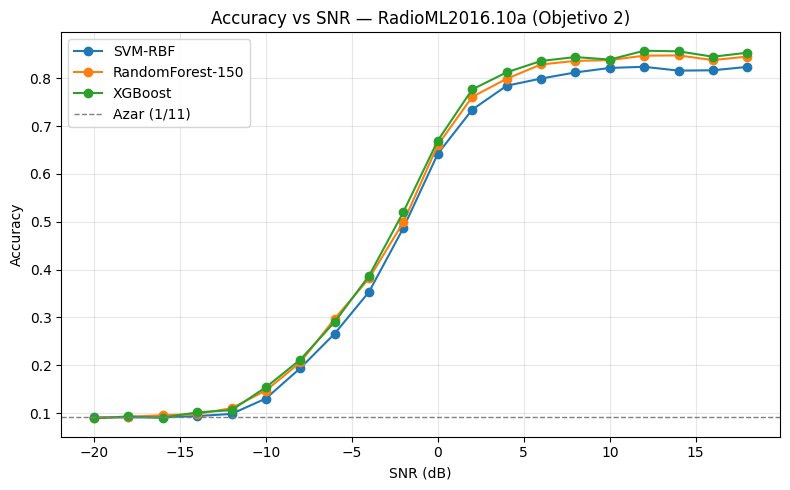

In [ ]:
preds = {'SVM-RBF': pred_svm, 'RandomForest-150': pred_rf, 'XGBoost': pred_xgb}

# --- Tabla global ---
global_df = pd.DataFrame([eval_global(n, yte, p) for n, p in preds.items()]).round(4)
print("=== Métricas globales (todos los SNR) ===")
print(global_df.to_string(index=False))

# --- Accuracy por SNR + curva ---
snr_tables = {}
plt.figure(figsize=(8, 5))
for n, p in preds.items():
    t = acc_por_snr(yte, p, snr_te)
    snr_tables[n] = t
    plt.plot(t['snr'], t['accuracy'], marker='o', label=n)

plt.axhline(1/len(classes), ls='--', c='gray', lw=1, label='Azar (1/11)')
plt.xlabel('SNR (dB)'); plt.ylabel('Accuracy')
plt.title('Accuracy vs SNR — RadioML2016.10a (Objetivo 2)')
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig('accuracy_vs_snr.png', dpi=150)
plt.show()

## 10. Matrices de confusión

> **[REPORTADO]** Se reportan matrices de confusión a SNR específicos, típicamente SNR alto (≥10 dB),
> donde los errores son interpretables (p. ej. confusión QAM16↔QAM64, WBFM↔AM-DSB). (O'Shea 2016; Rajendran 2018).

Se muestra la del **mejor modelo** (por accuracy global) en SNR alto, y la global.

Mejor modelo por accuracy global: XGBoost


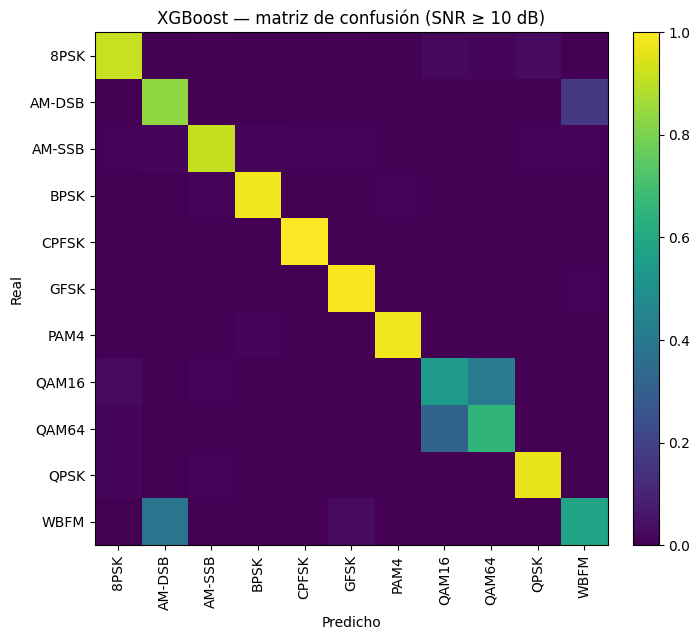

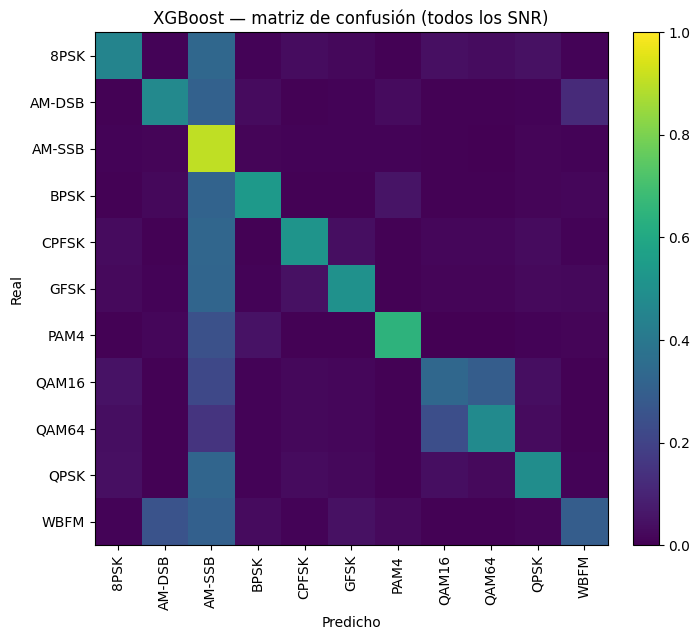

In [ ]:
def plot_cm(ytrue, ypred, titulo, fname=None):
    cm = confusion_matrix(ytrue, ypred, labels=range(len(classes)), normalize='true')
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(cm, vmin=0, vmax=1, cmap='viridis')
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=90)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(titulo)
    fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout()
    if fname: plt.savefig(fname, dpi=150)
    plt.show()

best_name = global_df.sort_values('accuracy', ascending=False).iloc[0]['modelo']
best_pred = preds[best_name]
print("Mejor modelo por accuracy global:", best_name)

# CM en SNR alto (>= 10 dB)
hi = snr_te >= 10
plot_cm(yte[hi], best_pred[hi], f'{best_name} — matriz de confusión (SNR ≥ 10 dB)',
        'cm_best_highsnr.png')

# CM global
plot_cm(yte, best_pred, f'{best_name} — matriz de confusión (todos los SNR)',
        'cm_best_global.png')

## 11. Guardado de resultados

Se persiste todo lo necesario para el análisis comparativo con los Objetivos 3–5: métricas, curvas por SNR,
reportes por clase, figuras y (opcionalmente) los modelos entrenados.

In [ ]:
import shutil



os.makedirs(RESULTS_DIR, exist_ok=True)

# 1) Métricas globales
global_df.to_csv(os.path.join(RESULTS_DIR, 'metricas_globales.csv'), index=False)

# 2) Accuracy vs SNR por modelo (formato ancho para graficar luego)
wide = None
for n, t in snr_tables.items():
    col = t[['snr', 'accuracy']].rename(columns={'accuracy': n})
    wide = col if wide is None else wide.merge(col, on='snr')
wide.to_csv(os.path.join(RESULTS_DIR, 'accuracy_vs_snr.csv'), index=False)

# 3) Reporte por clase (precision/recall/F1) de cada modelo
for n, p in preds.items():
    rep = classification_report(yte, p, target_names=classes,
                                output_dict=True, zero_division=0)
    pd.DataFrame(rep).transpose().to_csv(
        os.path.join(RESULTS_DIR, f'reporte_por_clase_{n}.csv'))

# 4) Figuras
for fig in ['accuracy_vs_snr.png', 'cm_best_highsnr.png', 'cm_best_global.png']:
    if os.path.exists(fig):
        shutil.move(fig, os.path.join(RESULTS_DIR, fig))

# 5) Modelos + objetos de preprocesamiento (opcional; ocupan espacio)
GUARDAR_MODELOS = True
if GUARDAR_MODELOS:
    joblib.dump(scaler, os.path.join(RESULTS_DIR, 'scaler.joblib'))
    joblib.dump(le,     os.path.join(RESULTS_DIR, 'label_encoder.joblib'))
    joblib.dump(rf,     os.path.join(RESULTS_DIR, 'modelo_rf.joblib'))
    joblib.dump(svm,    os.path.join(RESULTS_DIR, 'modelo_svm.joblib'))
    xgb.save_model(os.path.join(RESULTS_DIR, 'modelo_xgb.json'))

print("Resultados guardados en:", RESULTS_DIR)
print(sorted(os.listdir(RESULTS_DIR)))

Resultados guardados en: /content/drive/MyDrive/Sync GD/TESIS/Colab/Resultados/Objetivo2
['accuracy_vs_snr.csv', 'accuracy_vs_snr.png', 'cm_best_global.png', 'cm_best_highsnr.png', 'label_encoder.joblib', 'metricas_globales.csv', 'modelo_rf.joblib', 'modelo_svm.joblib', 'modelo_xgb.json', 'reporte_por_clase_RandomForest-150.csv', 'reporte_por_clase_SVM-RBF.csv', 'reporte_por_clase_XGBoost.csv', 'scaler.joblib']


---
### Cierre del Objetivo 2

Con esto quedan cubiertas las actividades 2.1–2.7: caracterización de la señal, partición/normalización
reproducible, los tres clasificadores entrenados y evaluados con el **mismo protocolo**, y resultados
persistidos para contrastarlos contra el Deep Learning (Objetivo 3) e IVRL (Objetivos 4–5).

**Para la redacción de la tesis, recuerda separar:**
- *Reportado por la literatura* (citado con `# [REPORTADO]`): split 50/50, RF=150 árboles, dependencia de features, rangos de accuracy.
- *Adaptación propia* (`# [ADAPTACIÓN]`): el vector de 16 features HOC+estadísticos, la estratificación por (mod, SNR).
- *Decisiones no reportadas justificadas* (`# [NO REPORTADO]`): hiperparámetros de SVM y XGBoost, subsample del SVM.
